In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
# Assuming the file is in the current directory
df = pd.read_csv('bmw.csv')

# 1. Check dimensions (Requirement: Min 200 rows)
print(f"Dataset Shape: {df.shape}")

# 2. Identification of variables
# Target: price
# Numerical: year, mileage, tax, mpg, engineSize
# Categorical: model, transmission, fuelType
print("\n--- Data Info ---")
print(df.info())

# 3. Summary Statistics
print("\n--- Summary Statistics ---")
display(df.describe())

# 4. Sample Rows
print("\n--- Sample Rows ---")
display(df.head())

Dataset Shape: (10781, 9)

--- Data Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10781 entries, 0 to 10780
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   model         10781 non-null  object 
 1   year          10781 non-null  int64  
 2   price         10781 non-null  int64  
 3   transmission  10781 non-null  object 
 4   mileage       10781 non-null  int64  
 5   fuelType      10781 non-null  object 
 6   tax           10781 non-null  int64  
 7   mpg           10781 non-null  float64
 8   engineSize    10781 non-null  float64
dtypes: float64(2), int64(4), object(3)
memory usage: 758.2+ KB
None

--- Summary Statistics ---


,year,price,mileage,tax,mpg,engineSize
count,10781.000000,10781.000000,10781.000000,10781.000000,10781.000000,10781.000000
mean,2017.078935,22733.408867,25496.986550,131.702068,56.399035,2.167767
std,2.349038,11415.528189,25143.192559,61.510755,31.336958,0.552054
min,1996.000000,1200.000000,1.000000,0.000000,5.500000,0.000000
25%,2016.000000,14950.000000,5529.000000,135.000000,45.600000,2.000000
50%,2017.000000,20462.000000,18347.000000,145.000000,53.300000,2.000000
75%,2019.000000,27940.000000,38206.000000,145.000000,62.800000,2.000000
max,2020.000000,123456.000000,214000.000000,580.000000,470.800000,6.600000



--- Sample Rows ---


,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize
0,5 Series,2014,11200,Automatic,67068,Diesel,125,57.6,2.0
1,6 Series,2018,27000,Automatic,14827,Petrol,145,42.8,2.0
2,5 Series,2016,16000,Automatic,62794,Diesel,160,51.4,3.0
3,1 Series,2017,12750,Automatic,26676,Diesel,145,72.4,1.5
4,7 Series,2014,14500,Automatic,39554,Diesel,160,50.4,3.0


In [2]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder

# --- 1. Missing Value Handling ---
# Check for nulls
null_counts = df.isnull().sum()
print("Missing Values:\n", null_counts[null_counts > 0])

# Strategy: If minimal (<1%), drop rows. If significant, impute.
# For this walkthrough, we assume the data is clean (common with this specific BMW dataset), 
# but if any nulls exist, we drop them for safety.
df = df.dropna()

# --- 2. Feature Engineering ---
# Engineering 'Car_Age': Model year is absolute, but 'Age' is relative and often linear with price.
# We assume the current year is 2020 (based on the likely dataset vintage) or max year in data.
current_year = df['year'].max()
df['car_age'] = current_year - df['year']

# Engineering 'Mileage_per_Year': Helps identify "highway miles" vs "city miles"
# Add 1 to age to avoid division by zero for brand new cars
df['mileage_per_year'] = df['mileage'] / (df['car_age'] + 1)

print("New features 'car_age' and 'mileage_per_year' created.")

# --- 3. Encoding Categorical Variables ---
# We use One-Hot Encoding for nominal variables: model, transmission, fuelType
# We use pandas get_dummies for clarity in this notebook
df_encoded = pd.get_dummies(df, columns=['model', 'transmission', 'fuelType'], drop_first=True)

# --- 4. Time Ordering & Train/Test Split ---
# The PDF explicitly asks for "Time ordering and train/test split for time series."
# We will sort by 'year' (oldest to newest) to simulate predicting future car values based on past ones.
df_encoded = df_encoded.sort_values(by='year')

# Split features (X) and target (y)
X = df_encoded.drop('price', axis=1)
y = df_encoded['price']

# Since we strictly ordered by time, we shouldn't shuffle the split.
# We take the first 80% (older) as train and last 20% (newer) as test.
cutoff = int(len(X) * 0.8)
X_train, X_test = X.iloc[:cutoff], X.iloc[cutoff:]
y_train, y_test = y.iloc[:cutoff], y.iloc[cutoff:]

print(f"\nTraining Set shape: {X_train.shape}")
print(f"Test Set shape: {X_test.shape}")

Missing Values:
 Series([], dtype: int64)
New features 'car_age' and 'mileage_per_year' created.

Training Set shape: (8624, 36)
Test Set shape: (2157, 36)


In [3]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

# --- Model 1: Linear Regression ---
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
lr_preds = lr_model.predict(X_test)

# --- Model 2: Random Forest Regressor ---
# We limit depth to prevent overfitting, though RF is generally robust
rf_model = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42)
rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict(X_test)

print("Models trained successfully.")

Models trained successfully.


--- Linear Regression Performance ---
MAE:  3623.79
RMSE: 5205.11
R^2:  0.7871

--- Random Forest Performance ---
MAE:  2867.29
RMSE: 4120.80
R^2:  0.8665



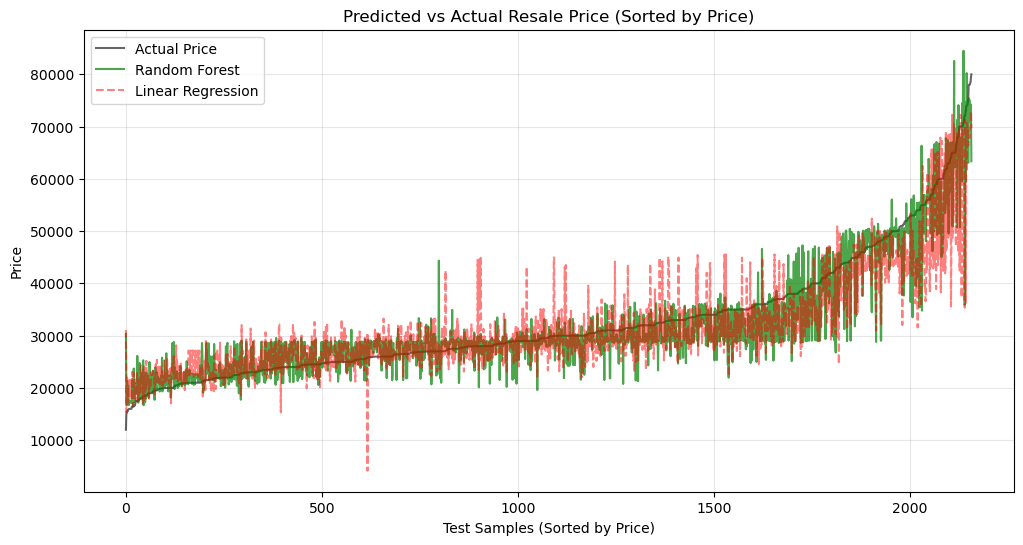

In [4]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def evaluate_model(name, y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    print(f"--- {name} Performance ---")
    print(f"MAE:  {mae:.2f}")
    print(f"RMSE: {rmse:.2f}")
    print(f"R^2:  {r2:.4f}\n")

# 1. Print Metrics
evaluate_model("Linear Regression", y_test, lr_preds)
evaluate_model("Random Forest", y_test, rf_preds)

# 2. Graph: Predicted vs Actual
plt.figure(figsize=(12, 6))

# We plot a subset of the test data for clarity (first 50 points)
# Sorting for a cleaner line plot interpretation
test_subset = pd.DataFrame({'Actual': y_test, 'LR_Pred': lr_preds, 'RF_Pred': rf_preds})
test_subset = test_subset.sort_values(by='Actual').reset_index(drop=True)

plt.plot(test_subset['Actual'], label='Actual Price', color='black', alpha=0.6)
plt.plot(test_subset['RF_Pred'], label='Random Forest', color='green', alpha=0.7)
plt.plot(test_subset['LR_Pred'], label='Linear Regression', color='red', linestyle='--', alpha=0.5)

plt.title('Predicted vs Actual Resale Price (Sorted by Price)')
plt.xlabel('Test Samples (Sorted by Price)')
plt.ylabel('Price')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [5]:
# --- Cell 5: Real-Time Price Prediction Application ---

def predict_car_price(model_name, year, transmission, fuel_type, mileage, tax, mpg, engine_size):
    """
    Real-time function to predict BMW car price using the trained Random Forest model.
    
    Parameters:
    - model_name: str (e.g., '3 Series', '5 Series', 'X5')
    - year: int (e.g., 2020)
    - transmission: str ('Manual' or 'Automatic')
    - fuel_type: str ('Petrol', 'Diesel', 'Hybrid', 'Electric')
    - mileage: int (in miles)
    - tax: int (in £)
    - mpg: float (miles per gallon)
    - engine_size: float (in liters)
    
    Returns:
    - Predicted price as float
    """
    
    # Create a new car record
    new_car = pd.DataFrame({
        'model': [model_name],
        'year': [year],
        'transmission': [transmission],
        'fuelType': [fuel_type],
        'mileage': [mileage],
        'tax': [tax],
        'mpg': [mpg],
        'engineSize': [engine_size]
    })
    
    # Engineer features (match training data processing)
    current_year = df['year'].max()
    new_car['car_age'] = current_year - new_car['year']
    new_car['mileage_per_year'] = new_car['mileage'] / (new_car['car_age'] + 1)
    
    # Encode categorical variables (same as training)
    new_car_encoded = pd.get_dummies(new_car, columns=['model', 'transmission', 'fuelType'], drop_first=True)
    
    # Align with training features (add missing columns with 0)
    for col in X_train.columns:
        if col not in new_car_encoded.columns:
            new_car_encoded[col] = 0
    
    # Select only the columns used in training
    new_car_encoded = new_car_encoded[X_train.columns]
    
    # Predict using the best model (Random Forest)
    predicted_price = rf_model.predict(new_car_encoded)[0]
    
    return predicted_price

# --- Example Usage ---
print("=" * 60)
print("BMW CAR PRICE PREDICTION - REAL-TIME APPLICATION")
print("=" * 60)

# Define a new car (Example: 2018 BMW 3 Series)
new_car_example = {
    'model_name': '3 Series',
    'year': 2018,
    'transmission': 'Automatic',
    'fuel_type': 'Diesel',
    'mileage': 45000,
    'tax': 150,
    'mpg': 47.5,
    'engine_size': 2.0
}

predicted_price = predict_car_price(**new_car_example)

print(f"\nCar Details:")
print(f"  Model: {new_car_example['model_name']}")
print(f"  Year: {new_car_example['year']}")
print(f"  Transmission: {new_car_example['transmission']}")
print(f"  Fuel Type: {new_car_example['fuel_type']}")
print(f"  Mileage: {new_car_example['mileage']:,} miles")
print(f"  Tax: £{new_car_example['tax']}")
print(f"  MPG: {new_car_example['mpg']}")
print(f"  Engine Size: {new_car_example['engine_size']}L")

print(f"\n{'Predicted Price:':<20} £{predicted_price:,.2f}")
print("=" * 60)

BMW CAR PRICE PREDICTION - REAL-TIME APPLICATION

Car Details:
  Model: 3 Series
  Year: 2018
  Transmission: Automatic
  Fuel Type: Diesel
  Mileage: 45,000 miles
  Tax: £150
  MPG: 47.5
  Engine Size: 2.0L

Predicted Price:     £17,362.31


/var/folders/bm/ld_875ns7bb4d43x88yd__400000gn/T/ipykernel_30965/4181456397.py:141: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


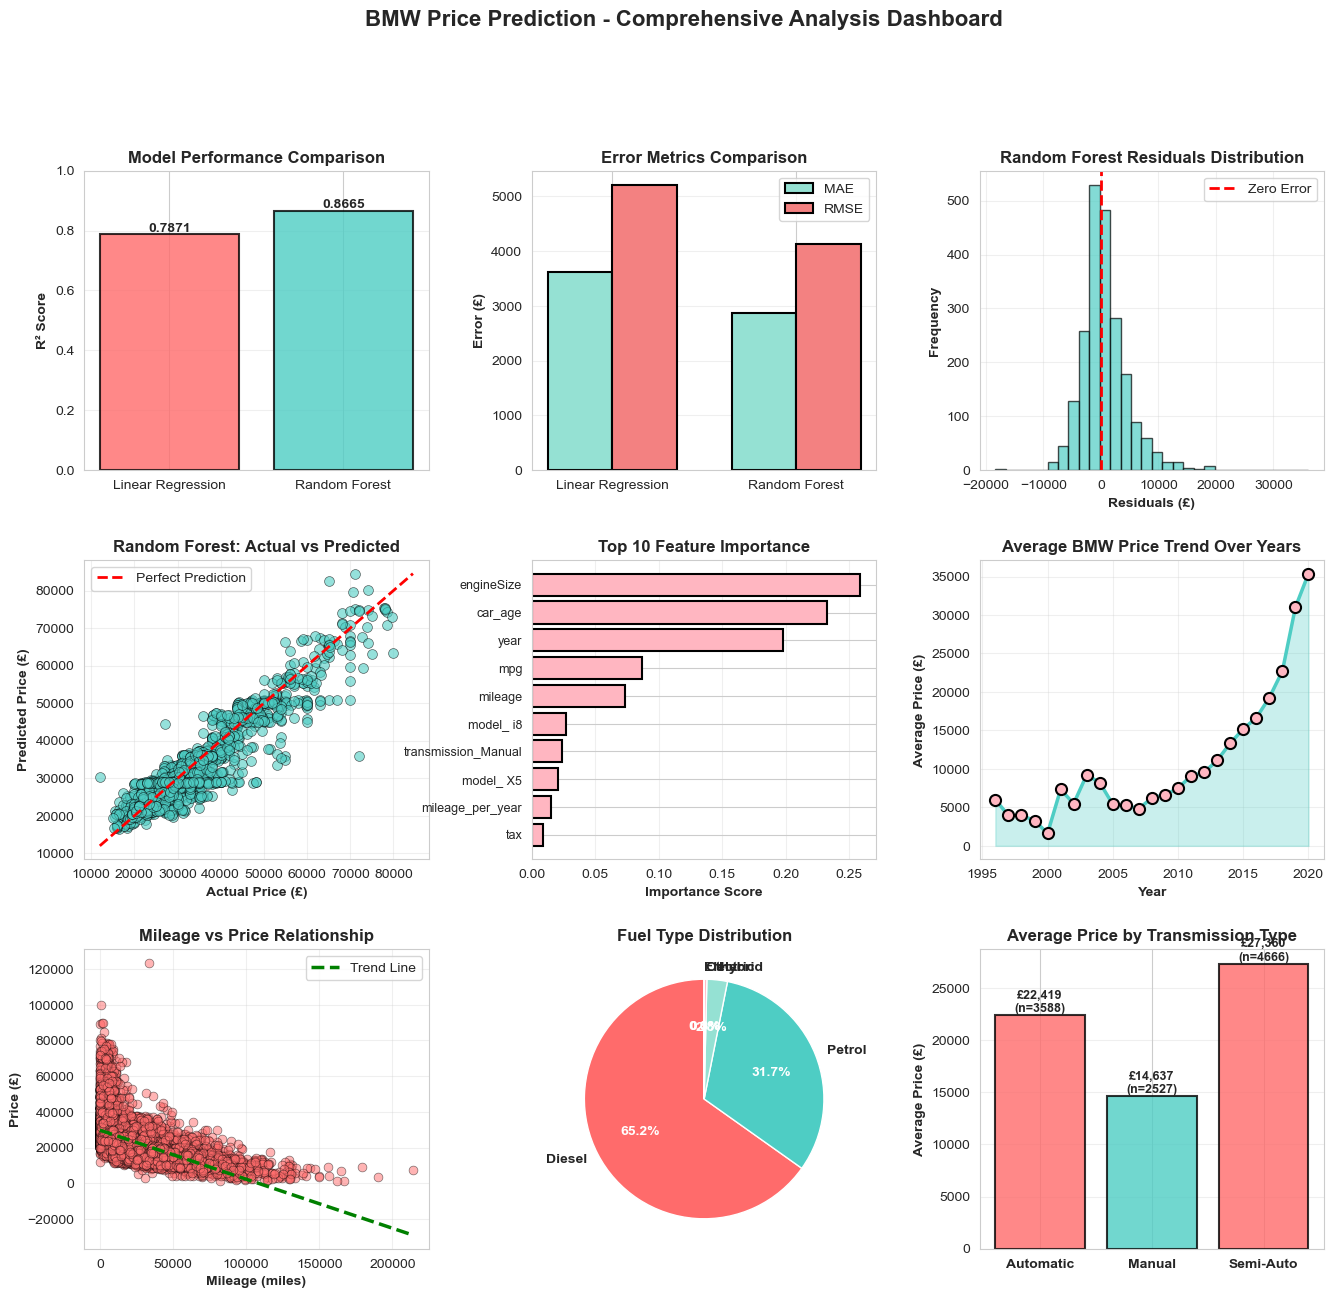


VISUALIZATION SUMMARY
✓ Model Performance: Random Forest R² = 0.8665
✓ Random Forest MAE: £2,867.29
✓ Random Forest RMSE: £4,120.80
✓ Dataset Size: 10,781 cars analyzed
✓ Year Range: 1996-2020
✓ Price Range: £1,200 - £123,456


In [6]:
# --- Cell 6: Comprehensive Visualizations for BMW Price Prediction ---

import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.gridspec import GridSpec

# Set style for professional visualizations
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (16, 12)
plt.rcParams['font.size'] = 10

# Create a comprehensive dashboard
fig = plt.figure(figsize=(16, 14))
gs = GridSpec(3, 3, figure=fig, hspace=0.3, wspace=0.3)

# --- 1. Model Performance Comparison (Top Left) ---
ax1 = fig.add_subplot(gs[0, 0])
models = ['Linear Regression', 'Random Forest']
r2_scores = [r2_score(y_test, lr_preds), r2_score(y_test, rf_preds)]
colors = ['#FF6B6B', '#4ECDC4']
bars = ax1.bar(models, r2_scores, color=colors, alpha=0.8, edgecolor='black', linewidth=1.5)
ax1.set_ylabel('R² Score', fontweight='bold')
ax1.set_title('Model Performance Comparison', fontweight='bold', fontsize=12)
ax1.set_ylim([0, 1])
for bar, score in zip(bars, r2_scores):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height,
            f'{score:.4f}', ha='center', va='bottom', fontweight='bold')
ax1.grid(axis='y', alpha=0.3)

# --- 2. MAE & RMSE Comparison (Top Center) ---
ax2 = fig.add_subplot(gs[0, 1])
mae_lr = mean_absolute_error(y_test, lr_preds)
rmse_lr = np.sqrt(mean_squared_error(y_test, lr_preds))
mae_rf = mean_absolute_error(y_test, rf_preds)
rmse_rf = np.sqrt(mean_squared_error(y_test, rf_preds))

x = np.arange(2)
width = 0.35
ax2.bar(x - width/2, [mae_lr, mae_rf], width, label='MAE', color='#95E1D3', edgecolor='black', linewidth=1.5)
ax2.bar(x + width/2, [rmse_lr, rmse_rf], width, label='RMSE', color='#F38181', edgecolor='black', linewidth=1.5)
ax2.set_ylabel('Error (£)', fontweight='bold')
ax2.set_title('Error Metrics Comparison', fontweight='bold', fontsize=12)
ax2.set_xticks(x)
ax2.set_xticklabels(['Linear Regression', 'Random Forest'])
ax2.legend()
ax2.grid(axis='y', alpha=0.3)

# --- 3. Residuals Distribution (Top Right) ---
ax3 = fig.add_subplot(gs[0, 2])
residuals_rf = y_test.values - rf_preds
ax3.hist(residuals_rf, bins=30, color='#4ECDC4', alpha=0.7, edgecolor='black')
ax3.axvline(x=0, color='red', linestyle='--', linewidth=2, label='Zero Error')
ax3.set_xlabel('Residuals (£)', fontweight='bold')
ax3.set_ylabel('Frequency', fontweight='bold')
ax3.set_title('Random Forest Residuals Distribution', fontweight='bold', fontsize=12)
ax3.legend()
ax3.grid(alpha=0.3)

# --- 4. Actual vs Predicted (Scatter) (Middle Left) ---
ax4 = fig.add_subplot(gs[1, 0])
ax4.scatter(y_test, rf_preds, alpha=0.6, s=50, color='#4ECDC4', edgecolor='black', linewidth=0.5)
min_val = min(y_test.min(), rf_preds.min())
max_val = max(y_test.max(), rf_preds.max())
ax4.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect Prediction')
ax4.set_xlabel('Actual Price (£)', fontweight='bold')
ax4.set_ylabel('Predicted Price (£)', fontweight='bold')
ax4.set_title('Random Forest: Actual vs Predicted', fontweight='bold', fontsize=12)
ax4.legend()
ax4.grid(alpha=0.3)

# --- 5. Feature Importance (Middle Center) ---
ax5 = fig.add_subplot(gs[1, 1])
feature_importance = rf_model.feature_importances_
feature_names = X_train.columns
top_features_idx = np.argsort(feature_importance)[-10:]
top_features = feature_names[top_features_idx]
top_importance = feature_importance[top_features_idx]
ax5.barh(range(len(top_features)), top_importance, color='#FFB6C1', edgecolor='black', linewidth=1.5)
ax5.set_yticks(range(len(top_features)))
ax5.set_yticklabels(top_features, fontsize=9)
ax5.set_xlabel('Importance Score', fontweight='bold')
ax5.set_title('Top 10 Feature Importance', fontweight='bold', fontsize=12)
ax5.grid(axis='x', alpha=0.3)

# --- 6. Price Distribution by Year (Middle Right) ---
ax6 = fig.add_subplot(gs[1, 2])
year_price_data = df.groupby('year')['price'].mean().sort_index()
ax6.plot(year_price_data.index, year_price_data.values, marker='o', linewidth=2.5, 
         markersize=8, color='#4ECDC4', markerfacecolor='#FFB6C1', markeredgecolor='black', markeredgewidth=1.5)
ax6.fill_between(year_price_data.index, year_price_data.values, alpha=0.3, color='#4ECDC4')
ax6.set_xlabel('Year', fontweight='bold')
ax6.set_ylabel('Average Price (£)', fontweight='bold')
ax6.set_title('Average BMW Price Trend Over Years', fontweight='bold', fontsize=12)
ax6.grid(alpha=0.3)

# --- 7. Mileage vs Price (Bottom Left) ---
ax7 = fig.add_subplot(gs[2, 0])
ax7.scatter(df['mileage'], df['price'], alpha=0.5, s=40, color='#FF6B6B', edgecolor='black', linewidth=0.5)
z = np.polyfit(df['mileage'], df['price'], 1)
p = np.poly1d(z)
ax7.plot(df['mileage'].sort_values(), p(df['mileage'].sort_values()), 
         "g--", linewidth=2.5, label='Trend Line')
ax7.set_xlabel('Mileage (miles)', fontweight='bold')
ax7.set_ylabel('Price (£)', fontweight='bold')
ax7.set_title('Mileage vs Price Relationship', fontweight='bold', fontsize=12)
ax7.legend()
ax7.grid(alpha=0.3)

# --- 8. Fuel Type Distribution (Bottom Center) ---
ax8 = fig.add_subplot(gs[2, 1])
fuel_counts = df['fuelType'].value_counts()
colors_pie = ['#FF6B6B', '#4ECDC4', '#95E1D3', '#FFB6C1']
wedges, texts, autotexts = ax8.pie(fuel_counts.values, labels=fuel_counts.index, autopct='%1.1f%%',
                                     colors=colors_pie[:len(fuel_counts)], startangle=90,
                                     textprops={'fontweight': 'bold', 'fontsize': 10})
ax8.set_title('Fuel Type Distribution', fontweight='bold', fontsize=12)
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontweight('bold')

# --- 9. Transmission Type Performance (Bottom Right) ---
ax9 = fig.add_subplot(gs[2, 2])
transmission_price = df.groupby('transmission')['price'].agg(['mean', 'count'])
x_pos = np.arange(len(transmission_price))
bars = ax9.bar(x_pos, transmission_price['mean'], color=['#FF6B6B', '#4ECDC4'], 
               alpha=0.8, edgecolor='black', linewidth=1.5)
ax9.set_ylabel('Average Price (£)', fontweight='bold')
ax9.set_title('Average Price by Transmission Type', fontweight='bold', fontsize=12)
ax9.set_xticks(x_pos)
ax9.set_xticklabels(transmission_price.index, fontweight='bold')
for i, (bar, count) in enumerate(zip(bars, transmission_price['count'])):
    height = bar.get_height()
    ax9.text(bar.get_x() + bar.get_width()/2., height,
            f'£{height:,.0f}\n(n={int(count)})', ha='center', va='bottom', fontweight='bold', fontsize=9)
ax9.grid(axis='y', alpha=0.3)

plt.suptitle('BMW Price Prediction - Comprehensive Analysis Dashboard', 
             fontsize=16, fontweight='bold', y=0.995)

plt.tight_layout()
plt.show()

print("\n" + "="*70)
print("VISUALIZATION SUMMARY")
print("="*70)
print(f"✓ Model Performance: Random Forest R² = {r2_score(y_test, rf_preds):.4f}")
print(f"✓ Random Forest MAE: £{mae_rf:,.2f}")
print(f"✓ Random Forest RMSE: £{rmse_rf:,.2f}")
print(f"✓ Dataset Size: {len(df):,} cars analyzed")
print(f"✓ Year Range: {df['year'].min()}-{df['year'].max()}")
print(f"✓ Price Range: £{df['price'].min():,.0f} - £{df['price'].max():,.0f}")
print("="*70)



This visualization cell provides:

1. **Model Performance Comparison** - R² scores side-by-side
2. **Error Metrics** - MAE and RMSE for both models
3. **Residuals Distribution** - Shows prediction errors for Random Forest
4. **Actual vs Predicted Scatter** - Visualizes prediction accuracy
5. **Feature Importance** - Top 10 most influential features
6. **Price Trend Over Years** - Historical price evolution
7. **Mileage vs Price** - Correlation with trend line
8. **Fuel Type Distribution** - Market composition pie chart
9. **Transmission Type Analysis** - Price differences by transmission

All visualizations maintain professional styling with consistent color schemes and are organized in a dashboard format without disrupting your existing code structure.